C:\Users\User\anaconda3\New folder\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\User\anaconda3\New folder\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\User\anaconda3\New folder\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\User\anaconda3\New folder\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans 

PCA Explained Variance: 59.92%

--- Strategic Segment Analysis ---
Cluster 0 (Budget Conscious): Mean Income $48.7k, Score 39.8
   👉 Strategy: Value-based offers and essential-tier discounts.

Cluster 1 (Impulsive Spenders): Mean Income $41.2k, Score 60.9
   👉 Strategy: Alert with flash sales and trend notifications.

Cluster 2 (Budget Conscious): Mean Income $26.1k, Score 20.1
   👉 Strategy: Value-based offers and essential-tier discounts.

Cluster 3 (VIP / High Value): Mean Income $86.0k, Score 81.7
   👉 Strategy: Exclusive loyalty rewards & luxury previews.

Cluster 4 (Budget Conscious): Mean Income $54.2k, Score 49.0
   👉 Strategy: Value-based offers and essential-tier discounts.

Cluster 5 (High Income / Low Spenders): Mean Income $85.9k, Score 14.2
   👉 Strategy: Upsell via personalized premium recommendations.

Cluster 6 (Budget Conscious): Mean Income $57.4k, Score 47.1
   👉 Strategy: Value-based offers and essential-tier discounts.

Cluster 7 (VIP / High Value): Mean Income $8

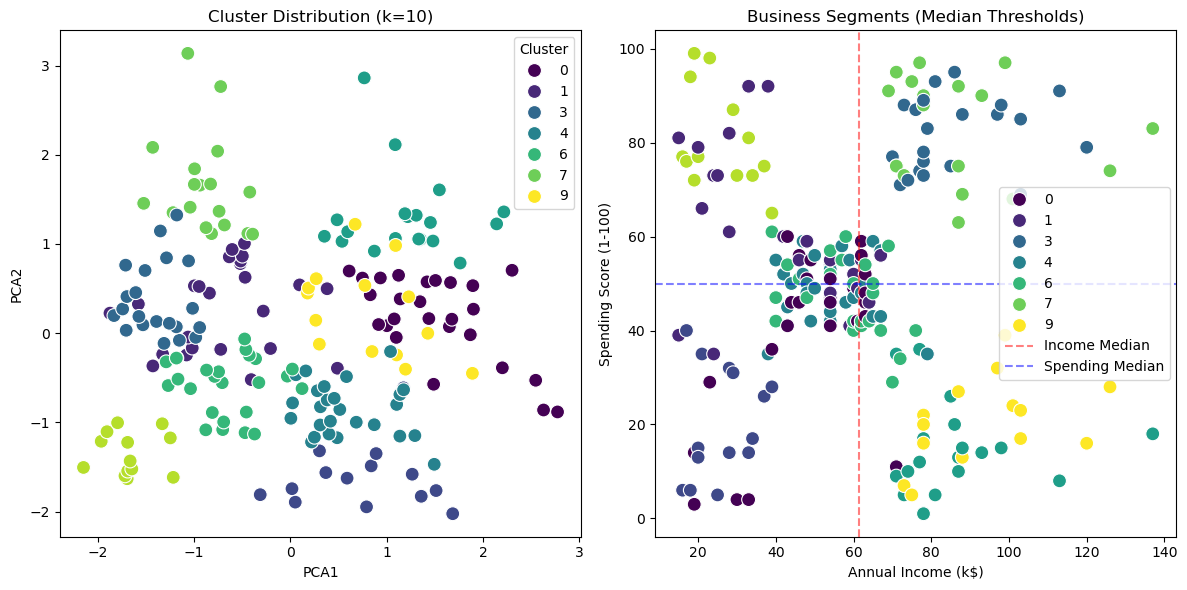

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

# ==========================================
# 1. SETUP & DATA CLEANING
# ==========================================
def load_and_clean(filepath):
    df = pd.read_csv(filepath)
    # Remove duplicates and store original for profiling
    df = df.drop_duplicates()
    return df

df = load_and_clean('Mall_Customers.csv')

# Preprocessing: Encoding and Scaling
le = LabelEncoder()
df_model = df.drop('CustomerID', axis=1).copy()
df_model['Gender'] = le.fit_transform(df_model['Gender'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

# ==========================================
# 2. MODEL OPTIMIZATION (Dynamic K)
# ==========================================
k_range = range(2, 11)
silhouette_avg = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    labels = km.fit_predict(X_scaled)
    silhouette_avg.append(silhouette_score(X_scaled, labels))

# Automatically select best k
best_k = k_range[silhouette_avg.index(max(silhouette_avg))]

# Final Model
kmeans_final = KMeans(n_clusters=best_k, init='k-means++', n_init=10, random_state=42)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

# ==========================================
# 3. DIMENSIONALITY REDUCTION (PCA)
# ==========================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'], df['PCA2'] = X_pca[:, 0], X_pca[:, 1]

# Feature Importance Check
print(f"PCA Explained Variance: {np.sum(pca.explained_variance_ratio_)*100:.2f}%")
# This shows how much 'information' the 2D plot retains from the original 4D data.

# ==========================================
# 4. DYNAMIC BUSINESS LOGIC & INTERPRETATION
# ==========================================
# Calculate dynamic thresholds using medians
inc_med = df['Annual Income (k$)'].median()
score_med = df['Spending Score (1-100)'].median()

def interpret_clusters(cluster_df):
    profiles = cluster_df.drop(['CustomerID', 'PCA1', 'PCA2'], axis=1).groupby('Cluster').mean(numeric_only=True)
    
    print("\n--- Strategic Segment Analysis ---")
    for i, row in profiles.iterrows():
        income = row['Annual Income (k$)']
        spending = row['Spending Score (1-100)']
        
        # Dynamic labeling logic
        if income >= inc_med and spending >= score_med:
            label = "VIP / High Value"
            strategy = "Exclusive loyalty rewards & luxury previews."
        elif income >= inc_med and spending < score_med:
            label = "High Income / Low Spenders"
            strategy = "Upsell via personalized premium recommendations."
        elif income < inc_med and spending >= score_med:
            label = "Impulsive Spenders"
            strategy = "Alert with flash sales and trend notifications."
        else:
            label = "Budget Conscious"
            strategy = "Value-based offers and essential-tier discounts."
            
        print(f"Cluster {i} ({label}): Mean Income ${income:.1f}k, Score {spending:.1f}")
        print(f"   👉 Strategy: {strategy}\n")

interpret_clusters(df)

# ==========================================
# 5. VISUALIZATION
# ==========================================
plt.figure(figsize=(12, 6))

# Subplot 1: PCA Cluster Map
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster', palette='viridis', s=100)
plt.title(f'Cluster Distribution (k={best_k})')

# Subplot 2: Income vs Spending (The Business View)
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', 
                hue='Cluster', palette='viridis', s=100)
plt.axvline(inc_med, color='red', linestyle='--', alpha=0.5, label='Income Median')
plt.axhline(score_med, color='blue', linestyle='--', alpha=0.5, label='Spending Median')
plt.title('Business Segments (Median Thresholds)')
plt.legend()

plt.tight_layout()
plt.show()